<a href="https://colab.research.google.com/github/shirshmohan/Kidney-Stone-Classfication-Project/blob/main/Swin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import torch as T
import shutil
import torch.nn as nn
import torchvision
from torchvision import models, transforms
from torch.utils.data import DataLoader, random_split
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

In [ ]:
class Config:
    device = T.device("cuda" if T.cuda.is_available() else "cpu")
    num_workers = 2
    model_name = "swin_base"
    pretrained = True
    num_classes = 4
    image_size = 224
    batch_size = 16
    epochs = 5
    lr = 1e-4
    patience = 5
    data_dir = "/content/drive/MyDrive/Kidney_Data/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone"
    save_dir = "/content/drive/MyDrive/Kidney_Data/Models"
    save_name = "swin_base_kidney_ct.pth"

    mean = [0.485, 0.456, 0.406]
    std = [0.229, 0.224, 0.225]

config = Config()

In [ ]:
train_transforms = transforms.Compose([
    transforms.Resize((config.image_size, config.image_size)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(config.mean, config.std)
])

val_transforms = transforms.Compose([
    transforms.Resize((config.image_size, config.image_size)),
    transforms.ToTensor(),
    transforms.Normalize(config.mean, config.std)
])

dataset = torchvision.datasets.ImageFolder(config.data_dir, transform=train_transforms)

In [ ]:
train_size = int(0.8 * len(dataset))
val_size = int(0.1 * len(dataset))
test_size = len(dataset) - train_size - val_size
train_set, val_set, test_set = random_split(dataset, [train_size, val_size, test_size])

train_loader = DataLoader(train_set, batch_size=config.batch_size, shuffle=True, num_workers=config.num_workers, pin_memory=True)
val_loader = DataLoader(val_set, batch_size=config.batch_size, shuffle=False, num_workers=config.num_workers, pin_memory=True)
test_loader = DataLoader(test_set, batch_size=config.batch_size, shuffle=False, num_workers=config.num_workers, pin_memory=True)

In [ ]:
class KidneyCTSwin(nn.Module):
    def __init__(self):
        super().__init__()
        if config.model_name == "swin_base":
            self.swin = models.swin_b(weights=models.Swin_B_Weights.DEFAULT)
        else:
            raise ValueError(f"Model {config.model_name} not supported.")
        for param in self.swin.parameters():
            param.requires_grad = False
        for name, param in self.swin.named_parameters():
            if "layers.2" in name or "layers.3" in name or "norm" in name or "head" in name:
                param.requires_grad = True
        in_features = self.swin.head.in_features
        self.swin.head = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.GELU(),
            nn.Dropout(0.5),
            nn.LayerNorm(512),
            nn.Linear(512, config.num_classes)
        )
    def forward(self, x):
        return self.swin(x)

In [ ]:
def setup_training():
    model = KidneyCTSwin().to(config.device)
    criterion = nn.CrossEntropyLoss()
    optimizer = T.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=config.lr, weight_decay=1e-4)
    scaler = T.amp.GradScaler("cuda")
    return model, criterion, optimizer, scaler

In [ ]:
def train_model():
    model, criterion, optimizer, scaler = setup_training()
    best_acc = 0.0
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    total_start = time.time()

    for epoch in range(config.epochs):
        print(f"\nEpoch {epoch+1}/{config.epochs}")
        start_time = time.time()

        model.train()
        train_loss, train_correct = 0.0, 0
        for images, labels in tqdm(train_loader, desc="Training"):
            images, labels = images.to(config.device), labels.to(config.device)

            with T.amp.autocast("cuda"):
                outputs = model(images)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

            train_loss += loss.item() * images.size(0)
            train_correct += (outputs.argmax(1) == labels).sum().item()

        model.eval()
        val_loss, val_correct = 0.0, 0
        with T.no_grad():
            for images, labels in tqdm(val_loader, desc="Validating"):
                images, labels = images.to(config.device), labels.to(config.device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                val_correct += (outputs.argmax(1) == labels).sum().item()

        train_loss /= len(train_loader.dataset)
        train_acc = train_correct / len(train_loader.dataset)
        val_loss /= len(val_loader.dataset)
        val_acc = val_correct / len(val_loader.dataset)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        if val_acc > best_acc:
            best_acc = val_acc
            T.save(model.state_dict(), os.path.join(config.save_dir, config.save_name))
            print(f"✅ Saved new best model with val_acc: {val_acc:.4f}")

        print(f"Train Loss: {train_loss:.4f} | Acc: {train_acc:.4f}")
        print(f"Val Loss: {val_loss:.4f} | Acc: {val_acc:.4f}")
        print(f"Epoch Time: {time.time() - start_time:.2f} seconds")

    print(f"\n⏱️ Total Training Time: {(time.time() - total_start)/60:.2f} minutes")
    return history, model

In [ ]:
def plot_metrics(history):
    epochs = range(1, len(history['train_acc']) + 1)
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_acc'], label='Train Acc')
    plt.plot(epochs, history['val_acc'], label='Val Acc')
    plt.title("Accuracy over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_loss'], label='Train Loss')
    plt.plot(epochs, history['val_loss'], label='Val Loss')
    plt.title("Loss over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.savefig(os.path.join(config.save_dir, "metrics_plot.png"))
    plt.show()

In [ ]:
def evaluate_model(model):
    model.load_state_dict(T.load(os.path.join(config.save_dir, config.save_name)))
    model.eval()
    all_preds, all_labels = [], []

    with T.no_grad():
        for images, labels in tqdm(test_loader, desc="Testing"):
            images = images.to(config.device)
            outputs = model(images)
            preds = outputs.argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    # Accuracy
    test_acc = np.mean(np.array(all_preds) == np.array(all_labels))
    print(f"\n🎯 Final Test Accuracy: {test_acc:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dataset.classes)
    disp.plot(cmap=plt.cm.Blues)
    plt.title("Confusion Matrix")
    plt.savefig(os.path.join(config.save_dir, "confusion_matrix.png"))
    plt.show()

    # Classification Report
    report = classification_report(all_labels, all_preds, target_names=dataset.classes)
    print("\n📋 Classification Report:\n", report)
    with open(os.path.join(config.save_dir, "classification_report.txt"), "w") as f:
        f.write(report)

🚀 Dataset: 12446 images | Train: 623 batches

🎯 Training Swin Transformer...
Downloading: "https://download.pytorch.org/models/swin_b-68c6b09e.pth" to /root/.cache/torch/hub/checkpoints/swin_b-68c6b09e.pth


100%|██████████| 335M/335M [00:02<00:00, 122MB/s]



Epoch 1/5


Validating: 100%|██████████| 78/78 [04:28<00:00,  3.44s/it]


✅ Saved new best model with val_acc: 0.8987
Train Loss: 0.6163 | Acc: 0.7675
Val Loss: 0.2866 | Acc: 0.8987
Epoch Time: 2757.42 seconds

Epoch 2/5


...

Train Loss: 0.2490 | Acc: 0.9095
Val Loss: 0.1535 | Acc: 0.9397
Epoch Time: 169.09 seconds

Epoch 4/5


Validating: 100%|██████████| 78/78 [00:17<00:00,  4.48it/s]


✅ Saved new best model with val_acc: 0.9646
Train Loss: 0.2044 | Acc: 0.9239
Val Loss: 0.0961 | Acc: 0.9646
Epoch Time: 166.17 seconds

Epoch 5/5


Validating: 100%|██████████| 78/78 [00:17<00:00,  4.45it/s]


✅ Saved new best model with val_acc: 0.9767
Train Loss: 0.1698 | Acc: 0.9403
Val Loss: 0.0760 | Acc: 0.9767
Epoch Time: 170.02 seconds

⏱️ Total Training Time: 57.23 minutes


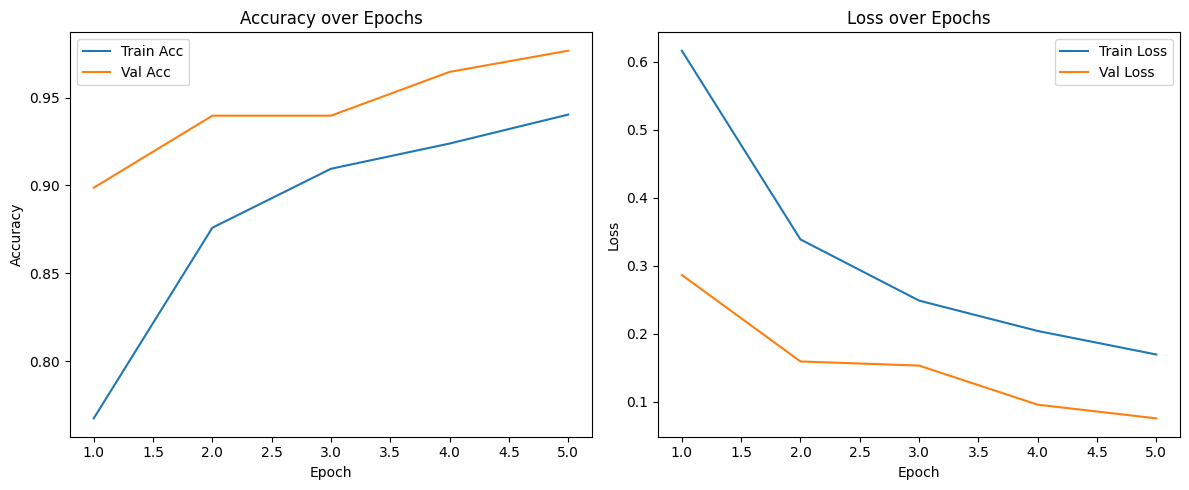

Testing: 100%|██████████| 78/78 [04:37<00:00,  3.55s/it]



🎯 Final Test Accuracy: 0.9727


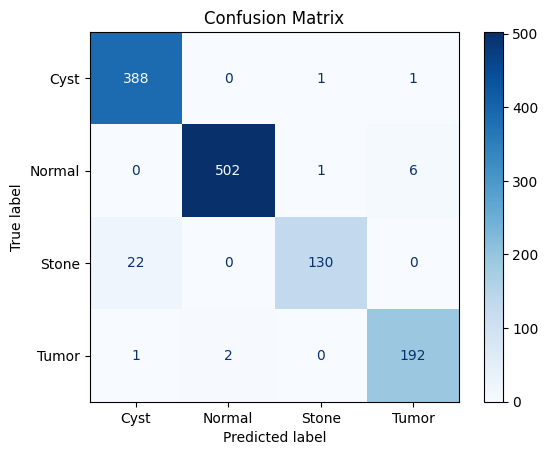


📋 Classification Report:
               precision    recall  f1-score   support

        Cyst       0.94      0.99      0.97       390
      Normal       1.00      0.99      0.99       509
       Stone       0.98      0.86      0.92       152
       Tumor       0.96      0.98      0.97       195

    accuracy                           0.97      1246
   macro avg       0.97      0.96      0.96      1246
weighted avg       0.97      0.97      0.97      1246

✅ SAVED to Drive: /content/drive/MyDrive/Kidney_Data/Model/swin_transformer.pkl
✅ ZIP created with all files!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

🎉 DOWNLOADING to C:\Users\KIIT0001\Downloads\!
📂 Extract to: Kidney_Data\Model

✅ COMPLETE! Files:
   → swin_transformer.pkl (model)
   → training_curves.png
   → confusion_matrix.png
   → report.txt


In [ ]:
from google.colab import files
import shutil

if __name__ == "__main__":
    print(f"🚀 Dataset: {len(dataset)} images | Train: {len(train_loader)} batches")
    os.makedirs(config.save_dir, exist_ok=True)

    print("\n🎯 Training Swin Transformer...")
    history, model = train_model()

    plot_metrics(history)

    evaluate_model(model)

    drive_path = "/content/drive/MyDrive/Kidney_Data/Model"
    os.makedirs(drive_path, exist_ok=True)
    T.save(model, f"{drive_path}/swin_transformer.pkl")
    print(f"✅ SAVED to Drive: {drive_path}/swin_transformer.pkl")

    zip_name = "/content/kidney_swin_transformer_complete.zip"
    shutil.make_archive(zip_name.replace('.zip', ''), 'zip', config.save_dir)
    print("✅ ZIP created with all files!")

    files.download(zip_name)
    print("🎉 DOWNLOADING to C:\\Users\\KIIT0001\\Downloads\\!")
    print("📂 Extract to: Kidney_Data\\Model")

    print("\n✅ COMPLETE! Files:")
    print("   → swin_transformer.pkl (model)")
    print("   → training_curves.png")
    print("   → confusion_matrix.png")
    print("   → report.txt")

In [ ]:
# Print classes (run anytime)
print("🏷️ Classes:", dataset.classes)
print("📊 Class indices:")
for i, cls in enumerate(dataset.classes):
    print(f"  {i}: {cls}")

🏷️ Classes: ['Cyst', 'Normal', 'Stone', 'Tumor']
📊 Class indices:
  0: Cyst
  1: Normal
  2: Stone
  3: Tumor
